# 1.0 Estudo de caso: construção de uma rede integrada de páginas da Wikipédia

## 1.1 Introdução: Fusão de Redes (Múltiplas SEEDS)

Este estudo de caso expande o método de *snowballing* (BFS) para construir uma rede mesclada a partir de **múltiplas páginas *seed*** (assuntos diferentes).

O objetivo é encontrar conexões entre os temas e construir uma rede que explore o contexto de cada *seed* até a **Camada 2 (profundidade < 3)**. Para mitigar o crescimento exponencial do BFS na Camada 2, implementaremos a heurística de **limitar o número máximo de links processados por página** (`MAX_LINKS_PER_PAGE`).

**As SEEDS escolhidas para a fusão são:**

* Graph
* UFRN
* Anime
* Basketball
* Forró

A rede resultante terá páginas (`nodes`) e os links entre elas (`edges`).

In [ ]:
!pip install wikipedia

## 1.2 Get the Data, Build the Network (Multi-Seed & Heurística)

### Definição de SEEDS e Parâmetros de Controle (Heurística)

Definimos `MAX_DEPTH = 3` para garantir que o *snowballing* explore até a Camada 2 (distância 2 da *seed*). A heurística `MAX_LINKS_PER_PAGE` limita a explosão da Camada 2 causada por *hubs* (páginas com muitos links).


In [ ]:
from operator import itemgetter
import networkx as nx
import wikipedia
import matplotlib.pyplot as plt

# 1. Definição das 5 SEEDS iniciais
SEEDS = ["Graph",
         "UFRN",
         "Anime",
         "Basketball",
         "Forró"]
SEEDS = [s.title() for s in SEEDS]

MAX_DEPTH = 3 # layer < 3 (Explora até a camada 2)
MAX_LINKS_PER_PAGE = 50 # HEURÍSTICA: Limite de links a processar por página.

STOPS = ("International Standard Serial Number",
         "International Standard Book Number",
         "National Diet Library",
         "International Standard Name Identifier",
         "International Standard Book Number (Identifier)",
         "Pubmed Identifier",
         "Pubmed Central",
         "Digital Object Identifier",
         "Arxiv",
         "Proc Natl Acad Sci Usa",
         "Bibcode",
         "Library Of Congress Control Number",
         "Jstor",
         "Doi (Identifier)",
         "Isbn (Identifier)",
         "Pmid (Identifier)",
         "Arxiv (Identifier)",
         "Bibcode (Identifier)",

         # STOPS de Cultura/Geografia/Termos Genéricos 
         "Brazil",
         "Rio Grande Do Norte",
         "Portuguese Language",
         "Japanese Language",
         "Sport",
         "Music",
         "Athlete",
         "Music Genre",
         "Musical Instrument",
         "Film",
         "Television",
         "20Th Century",
         "21St Century",

         # Hubs Biológicos/Taxonômicos
         "Animal",
         "Amorphea",
         "Amoebozoa",
         "Apicomplexa",
         "Bacteria",
         "Archaea",
         "Arthropod",
         "Actinophryid",
         "Algae",
         "Alveolate",
         "Archaeplastida",
         "Acidobacteriota",
         "Actinomycetota",
         "Anaeramoeba",
         "Ancyromonadida",
         "Archamoebea",
         "Armatimonadota",
         "Aquificota",
         "Bacillota",
         "Altarchaeota",
         "Anaeromonadea",
         "Apusomonadidae",

         # Hubs de Bases de Dados/Agregadores
         "Catalogue Of Life",
         "Global Biodiversity Information Facility",
         "Encyclopedia Of Life",
         "Algaebase",
         "Wikidata",
         "National Center For Biotechnology Information",
         "Animal Diversity Web",
         "Inaturalist",
         "Barcode Of Life Data System",

         # Hubs Esportivos/Históricos/Unidades
         "Baseball",
         "Ancient Greek",
         "Ancient Greece",
         "Australia",
         "Argentina",
         "Canada",
         "Belgium",
         "Ampere",
         "Centimetre–Gram–Second System Of Units",
         "Avoirdupois",
         "2019 Revision Of The Si",
         "American English",
         "American Football",
         "American League",
         "Bass Guitar",
         "American Football"
)

# 2. Inicialização do Snowballing (BFS)

# Inicializa com todas as SEEDS na camada 0
todo_lst = [(0, seed) for seed in SEEDS]
todo_set = set(SEEDS)
done_set = set()

g = nx.DiGraph()

layer, page = todo_lst[0]
print(f"Iniciando com {len(SEEDS)} SEEDS: {SEEDS}")

Iniciando com 5 SEEDS: ['Graph', 'Ufrn', 'Anime', 'Basketball', 'Forró']


### Loop Principal de Coleta e Construção da Rede

In [ ]:
%%time

while todo_lst and layer < MAX_DEPTH:

  # Remove o item atual e adiciona ao conjunto de páginas processadas.
  del todo_lst[0]
  done_set.add(page)

  # Mostra o progresso
  print(f"Processando: Camada {layer}, Página: {page}")

  wiki = None 
  try:
    wiki = wikipedia.page(page)
  except (wikipedia.exceptions.PageError,
          wikipedia.exceptions.DisambiguationError,
          wikipedia.exceptions.RedirectError) as e:
    print(f"\tERRO: Não foi possível carregar a página (erro da Wikipedia) {page}: {e}")
    # Tenta o próximo item
    if todo_lst:
        layer, page = todo_lst[0]
        continue
    else:
        break
  except Exception as e: # Captura qualquer outro erro inesperado durante o carregamento da página
    print(f"\tERRO: Erro inesperado ao carregar {page}: {e}")
    if todo_lst:
        layer, page = todo_lst[0]
        continue
    else:
        break

  # HEURÍSTICA: Limita a lista de links para controlar o crescimento da Camada 2
  links_to_process = []
  try:
      links_to_process = wiki.links[:MAX_LINKS_PER_PAGE]
      print(f"\tLinks encontrados: {len(wiki.links)}, Links processados (Heurística): {len(links_to_process)}")
  except (KeyError, AttributeError) as e: # Captura erros relacionados à obtenção de links
      print(f"\tAVISO: Não foi possível obter links para a página {page} devido a um erro: {e}. Pulando links.")
      
  for link in links_to_process:
    link = link.title()
    if link not in STOPS and not link.startswith("List Of"):
      if link not in todo_set and link not in done_set:
        # Adiciona à próxima camada (layer + 1)
        todo_lst.append((layer + 1, link))
        todo_set.add(link)
      # Sempre adiciona a aresta, mesmo que o nó já esteja em todo_set ou done_set
      g.add_edge(page, link)

  # Prepara o próximo item para a próxima iteração
  if todo_lst:
      layer, page = todo_lst[0]
  else:
      # Sai do loop se a lista estiver vazia
      break

print("--- Fim do Snowballing ---")

In [4]:
print("{} nodes, {} edges (Rede Bruta)".format(len(g), nx.number_of_edges(g)))

77567 nodes, 208668 edges (Rede Bruta)


## 1.3 Eliminar Duplicatas e Limpar a Rede

Aplicamos o processo de limpeza para mesclar nós duplicados (singular vs. plural e hífen vs. espaço) e remover *self-loops*.

Usamos `nx.contracted_nodes(g, u, v)` para fundir o nó `v` no nó `u`, reatribuindo todas as arestas.

In [5]:
# make a copy of raw graph
original = g.copy()

In [ ]:
# remove self loops
g.remove_edges_from(nx.selfloop_edges(g))

# identify duplicates like that: 'network' and 'networks'
duplicates_s = [(node, node + "s")
              for node in g if node + "s" in g
             ]

for dup in duplicates_s:
  # *dup is a technique named 'unpacking'
  u, v = dup
  # Check if both nodes exist before contracting
  if u in g and v in g:
    g = nx.contracted_nodes(g, u, v, self_loops=False)
  else:
    print(f"Skipping singular/plural contraction for '{u}' and '{v}' as one or both nodes are missing.")

print("Duplicatas (singular/plural) mescladas:", len(duplicates_s))

duplicates_hyphen = [(x, y) for x, y in
              [(node, node.replace("-", " ")) for node in g]
                if x != y and y in g]
print("Duplicatas (hífen/espaço) mescladas:", len(duplicates_hyphen))

for dup in duplicates_hyphen:
  u, v = dup
  if u in g and v in g:
    g = nx.contracted_nodes(g, u, v, self_loops=False)
  else:
    print(f"Skipping hyphen/space contraction for '{u}' and '{v}' as one or both nodes are missing.")

nx.set_node_attributes(g, 0,"contraction")
nx.set_edge_attributes(g, 0,"contraction")

Duplicatas (singular/plural) mescladas: 487
Duplicatas (hífen/espaço) mescladas: 100


In [7]:
print("{} nodes, {} edges (Rede Limpa)".format(len(g), nx.number_of_edges(g)))

76980 nodes, 206866 edges (Rede Limpa)


## 1.4 Truncar a Rede (Filtragem por Grau)

Para tornar a rede mais compacta e significativa, removeremos os nós com grau total (entrada + saída) menor que 2. Esses são nós 'folha' que apenas apontam para um link ou são apontados por um único link.

A **indegree** é a métrica de significância que queremos medir, pois ela representa o número de páginas que apontam para um determinado tópico (o quão referenciado ele é no nosso universo temático).

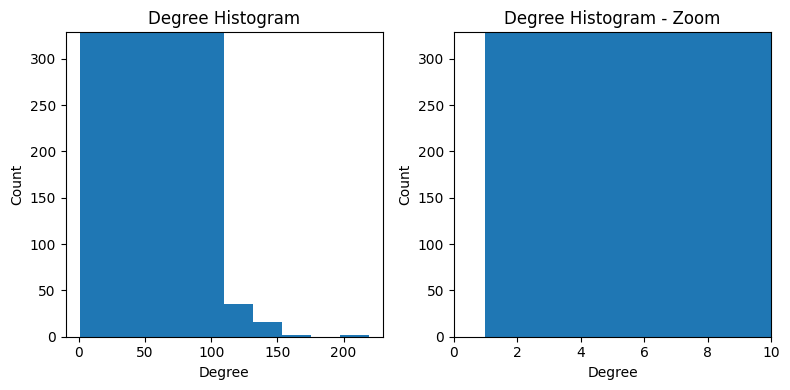

In [8]:
plt.style.use("default")
# degree sequence
degree_sequence = sorted([d for n, d in g.degree()], reverse=True)

fig, ax = plt.subplots(1,2,figsize=(8,4))

ax[0].hist(degree_sequence)
ax[1].hist(degree_sequence,bins=[1,2,3,4,5,6,7,8,9,10])

ax[0].set_title("Degree Histogram")
ax[0].set_ylabel("Count")
ax[0].set_xlabel("Degree")
ax[0].set_ylim(0, max(degree_sequence)*1.5)

ax[1].set_title("Degree Histogram - Zoom")
ax[1].set_ylabel("Count")
ax[1].set_xlabel("Degree")
ax[1].set_xlim(0,10)
ax[1].set_ylim(0, max(degree_sequence)*1.5)

plt.tight_layout()
plt.show()

In [9]:
# filter nodes with degree greater than or equal to 2
core = [node for node, deg in dict(g.degree()).items() if deg >= 2]

# select a subgraph with 'core' nodes
gsub = nx.subgraph(g, core)

print("{} nodes, {} edges (Rede Truncada)".format(len(gsub), nx.number_of_edges(gsub)))

# Exporta a rede para Gephi ou outras ferramentas
nx.write_graphml(gsub, "cna.graphml")

25883 nodes, 155769 edges (Rede Truncada)


### 1.5 Explore o Network: Top 100 Nós por Indegree

O *Indegree* (Grau de Entrada) de um nó é o número de links apontando para ele, representando sua **significância** (o quão referenciado é) dentro da nossa rede de assuntos mesclados.

O resultado a seguir mostra os 100 tópicos mais citados/significativos.

In [10]:
top_indegree = sorted(dict(gsub.in_degree()).items(),
                      reverse=True, key=itemgetter(1))[:100]
print("\n".join(map(lambda t: "Grau de Entrada: {} | Página: {}".format(*reversed(t)), top_indegree)))

Grau de Entrada: 158 | Página: Issn (Identifier)
Grau de Entrada: 120 | Página: Afrobeat
Grau de Entrada: 110 | Página: Africa
Grau de Entrada: 107 | Página: 1845 To 1868 In Baseball
Grau de Entrada: 104 | Página: Amino Acid
Grau de Entrada: 99 | Página: 1885 In Baseball
Grau de Entrada: 97 | Página: 1901 Major League Baseball Season
Grau de Entrada: 97 | Página: 1888 In Baseball
Grau de Entrada: 96 | Página: 1887 In Baseball
Grau de Entrada: 95 | Página: 1886 In Baseball
Grau de Entrada: 93 | Página: 1883 Major League Baseball Season
Grau de Entrada: 90 | Página: 1871 In Baseball
Grau de Entrada: 89 | Página: 1870 In Baseball
Grau de Entrada: 88 | Página: 1869 In Baseball
Grau de Entrada: 87 | Página: 1875 In Baseball
Grau de Entrada: 86 | Página: 1872 In Baseball
Grau de Entrada: 85 | Página: 1874 In Baseball
Grau de Entrada: 85 | Página: 1876 In Baseball
Grau de Entrada: 85 | Página: 1873 In Baseball
Grau de Entrada: 82 | Página: 1882 Major League Baseball Season
Grau de Entrada: 81

In [11]:
density = nx.density(gsub)
print(f"Densidade do grafo (gsub): {density:.4f}")

Densidade do grafo (gsub): 0.0002
